In [151]:
import torch
import torch.nn as nn
from torch.optim import Adam
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import *
import pickle
import time

In [110]:
# Use GPU if it is avaialable
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [111]:
test_df = pd.read_csv("Fashion_MNIST_dataset//fashion-mnist_test.csv").fillna(0)
train_df = pd.read_csv("Fashion_MNIST_dataset//fashion-mnist_train.csv").fillna(0)


y_train = train_df.label
y_train = torch.tensor(y_train.values, dtype=torch.long).to(device)

x_train = train_df.drop('label', axis=1)
x_train = torch.tensor(x_train.values, dtype=torch.float32).to(device)

y_test = test_df.label
y_test = torch.tensor(y_test.values, dtype=torch.long).to(device)

x_test = test_df.drop('label', axis=1)
x_test = torch.tensor(x_test.values, dtype=torch.float32).to(device)

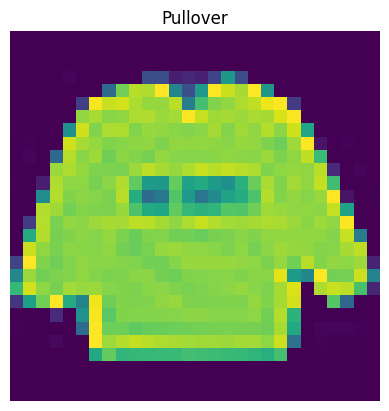

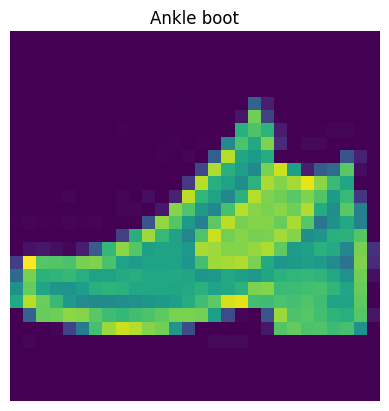

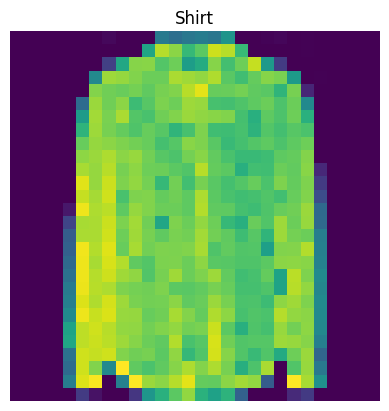

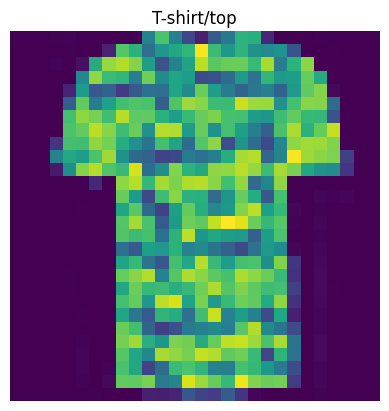

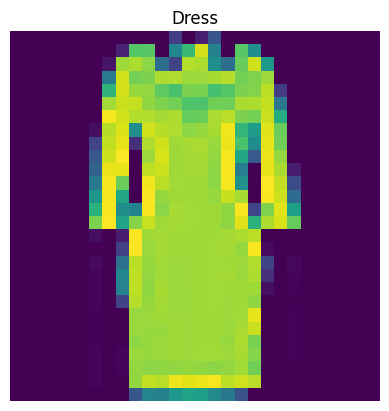

In [112]:
Labels = ["T-shirt/top" , "Trouser" , "Pullover" , "Dress" , "Coat" , "Sandal" , "Shirt" , "Sneaker" , "Bag" , "Ankle boot"]

# VISUALISING IMAGES
for i,j in zip(x_train[:5],y_train[:5]):
    i1 = i.cpu().reshape(28,28)
    plt.imshow(i1)
    plt.title(label=Labels[j.item()])
    plt.axis("off")
    plt.show()

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self , latent_dim):
        super().__init__()
        
        # Convert the image into its latent dimensions going 784 --> 512 --> 256 --> latent dimension
        self.encoder = nn.Sequential(
            nn.Linear(in_features=784 , out_features=512),
            nn.ReLU(),
            nn.Linear(in_features=512 , out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256 , out_features=latent_dim) 
        )

        # Convert the image back to into its original form or try to reconstruct the image from the latent dimension
        # latent dimension --> 256 --> 512 --> 784
        self.decoder = nn.Sequential(
            nn.Linear(in_features=latent_dim , out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256 , out_features=512),
            nn.ReLU(),
            nn.Linear(in_features=512 , out_features=784),
        )


    def forward(self , x):
        latent = self.encoder(x)
        x = self.decoder(latent)
        return x

----------AutoEncoder with Latent Dimension 2----------
Epoch : 0	Loss : 7407.455786132812
Epoch : 25	Loss : 1899.37109375
Epoch : 50	Loss : 1795.1389302571615
Epoch : 75	Loss : 1741.5248677571615
Epoch : 100	Loss : 1714.508827718099
Epoch : 125	Loss : 1692.9583455403647
Epoch : 150	Loss : 1682.5072001139322
Epoch : 175	Loss : 1663.3576985677084
Epoch : 200	Loss : 1655.983447265625
Epoch : 225	Loss : 1643.202256266276
Epoch : 250	Loss : 1633.209814453125


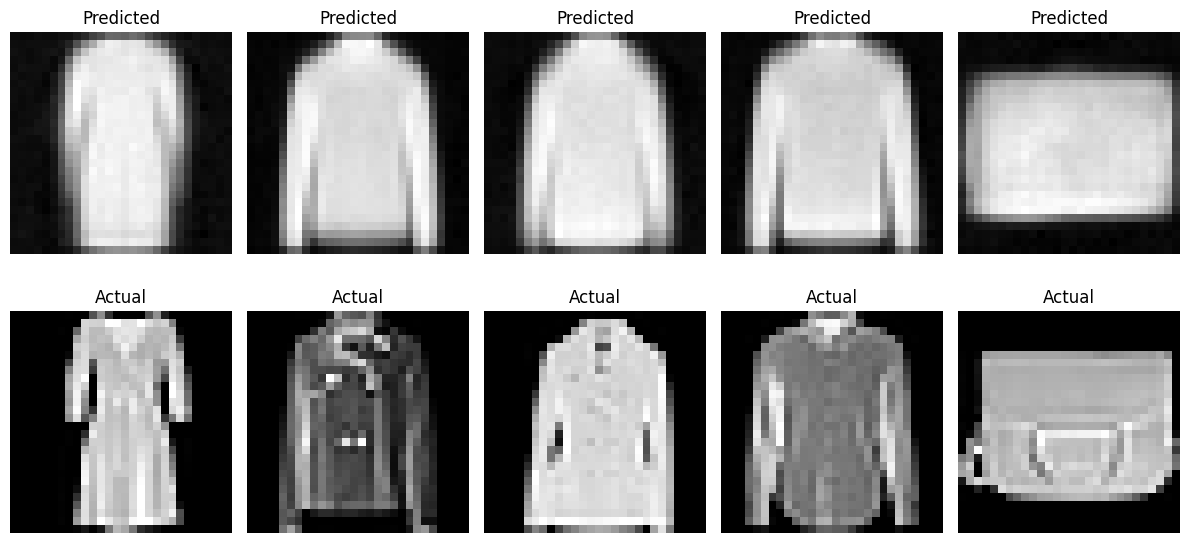

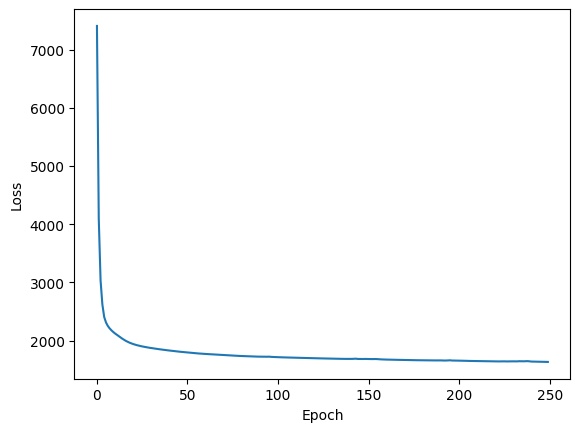




----------AutoEncoder with Latent Dimension 4----------
Epoch : 0	Loss : 7880.933272298177
Epoch : 25	Loss : 1340.1419799804687
Epoch : 50	Loss : 1267.3767740885417
Epoch : 75	Loss : 1230.8868876139322
Epoch : 100	Loss : 1206.3310648600261
Epoch : 125	Loss : 1187.651416015625
Epoch : 150	Loss : 1173.7835266113282
Epoch : 175	Loss : 1161.7499633789062
Epoch : 200	Loss : 1151.9173482259114
Epoch : 225	Loss : 1143.2880940755208
Epoch : 250	Loss : 1135.828751627604


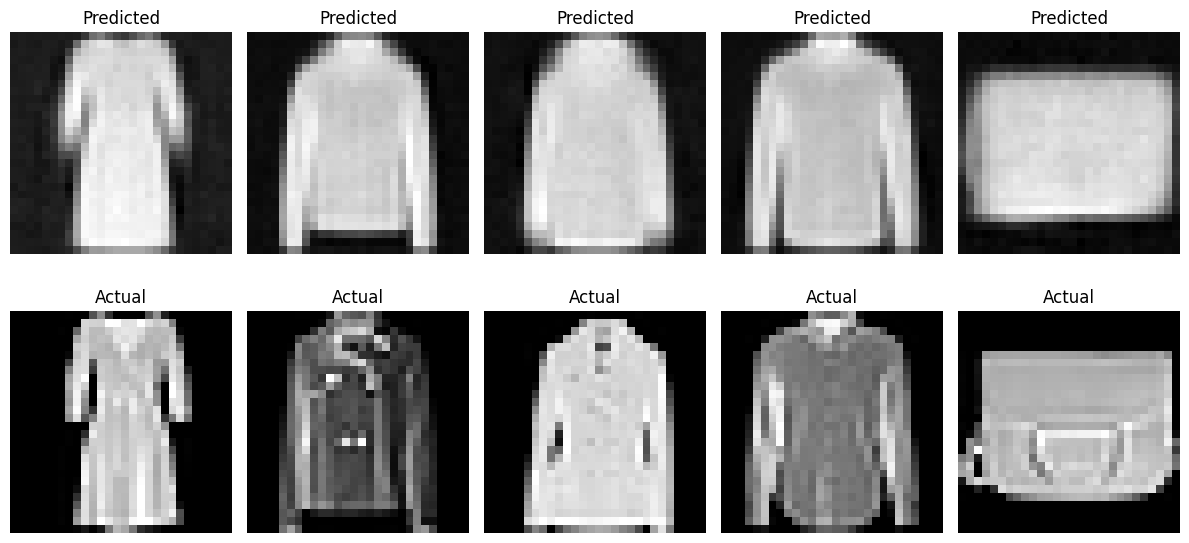

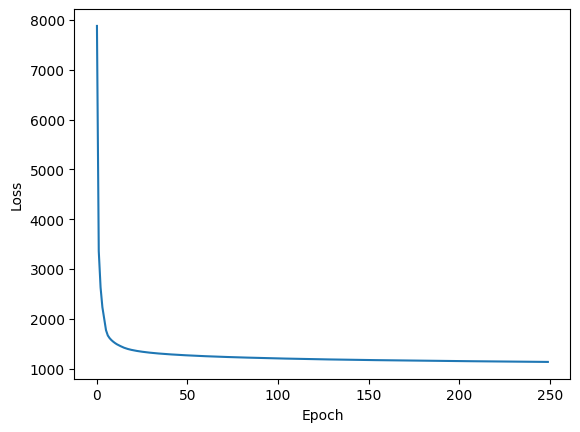




----------AutoEncoder with Latent Dimension 8----------
Epoch : 0	Loss : 8023.452905273438
Epoch : 25	Loss : 1111.4589050292968
Epoch : 50	Loss : 1015.8084991455078
Epoch : 75	Loss : 970.6593638102214
Epoch : 100	Loss : 941.6711771647135
Epoch : 125	Loss : 921.0294504801433
Epoch : 150	Loss : 905.3014190673828
Epoch : 175	Loss : 892.2172424316407
Epoch : 200	Loss : 881.3184855143229
Epoch : 225	Loss : 872.264481608073
Epoch : 250	Loss : 864.7148162841797


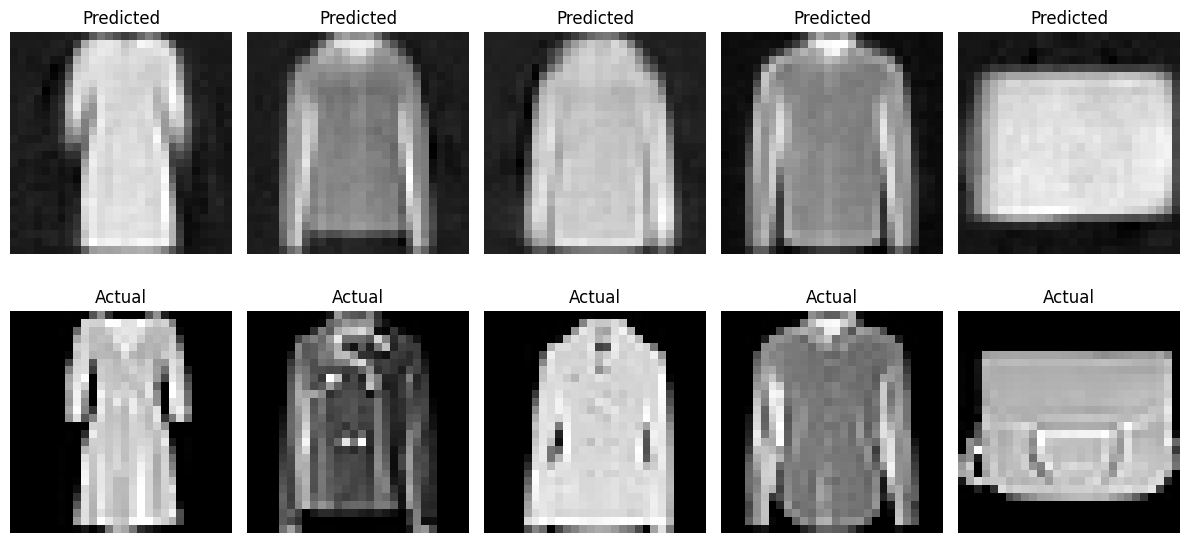

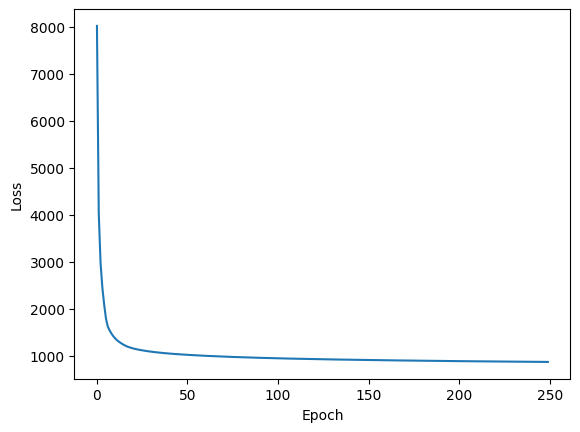




----------AutoEncoder with Latent Dimension 16----------
Epoch : 0	Loss : 8045.0449625651045
Epoch : 25	Loss : 1008.1889862060547
Epoch : 50	Loss : 887.6941223144531
Epoch : 75	Loss : 837.5247385660807
Epoch : 100	Loss : 806.9277414957683
Epoch : 125	Loss : 786.4717681884765
Epoch : 150	Loss : 771.275703938802
Epoch : 175	Loss : 759.2621002197266
Epoch : 200	Loss : 749.1314524332682
Epoch : 225	Loss : 740.5538736979166
Epoch : 250	Loss : 733.0863494873047


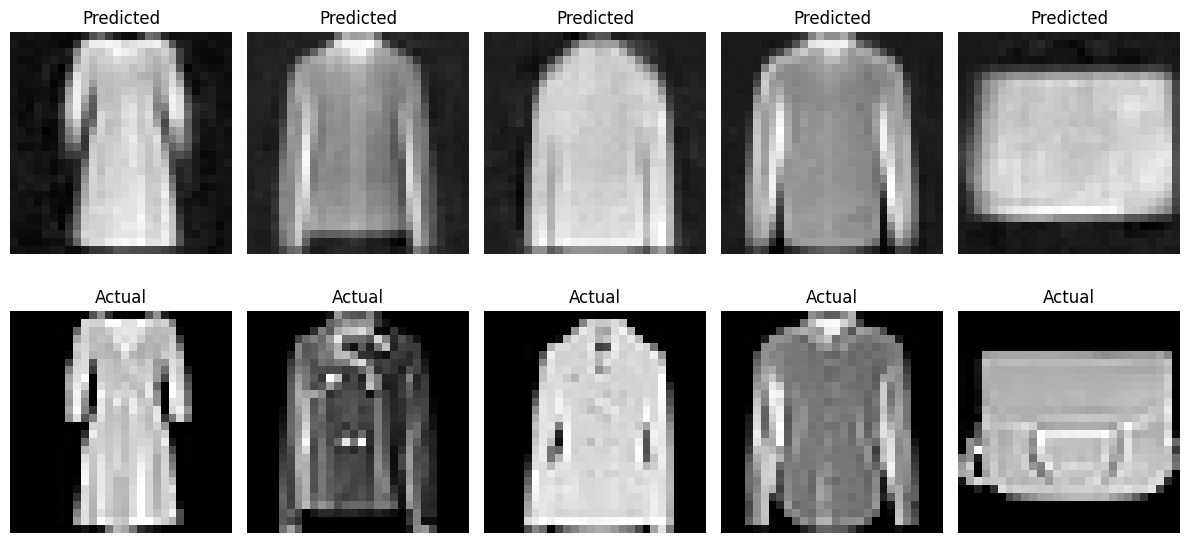

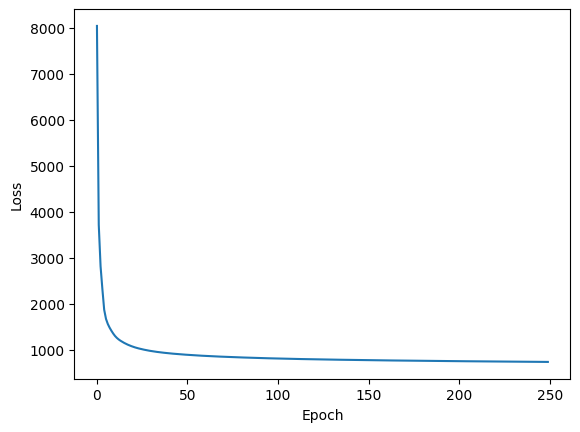




----------AutoEncoder with Latent Dimension 32----------
Epoch : 0	Loss : 8003.201961263021
Epoch : 25	Loss : 973.5853485107422
Epoch : 50	Loss : 812.4261891682943
Epoch : 75	Loss : 745.3016021728515
Epoch : 100	Loss : 707.929024251302
Epoch : 125	Loss : 682.6025950113932
Epoch : 150	Loss : 664.3566141764323
Epoch : 175	Loss : 650.6595255533854
Epoch : 200	Loss : 639.500542195638
Epoch : 225	Loss : 629.9487752278645
Epoch : 250	Loss : 622.3240295410156


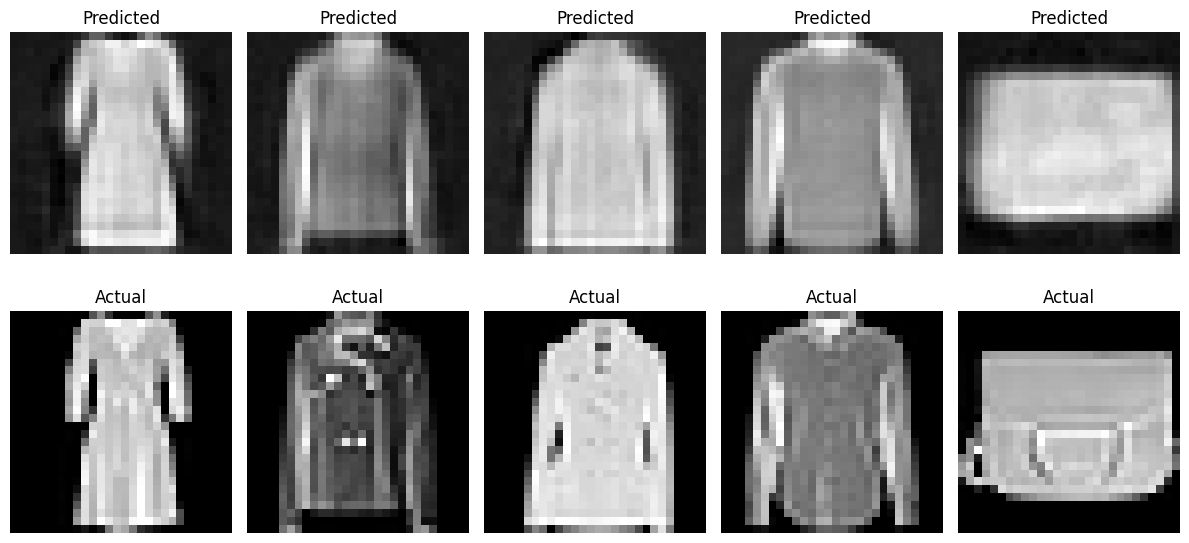

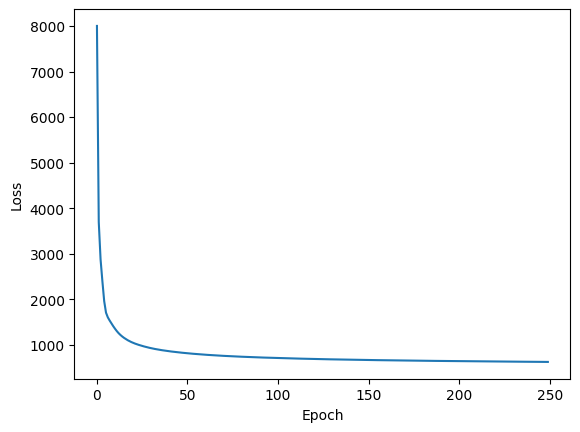




----------AutoEncoder with Latent Dimension 64----------
Epoch : 0	Loss : 8063.0027262369795
Epoch : 25	Loss : 950.0232686360677
Epoch : 50	Loss : 765.2703104654948
Epoch : 75	Loss : 675.3709920247396
Epoch : 100	Loss : 621.5277333577474
Epoch : 125	Loss : 585.100776163737
Epoch : 150	Loss : 558.7358683268229
Epoch : 175	Loss : 538.5761891682943
Epoch : 200	Loss : 522.9935612996419
Epoch : 225	Loss : 509.1419158935547
Epoch : 250	Loss : 499.11515452067056


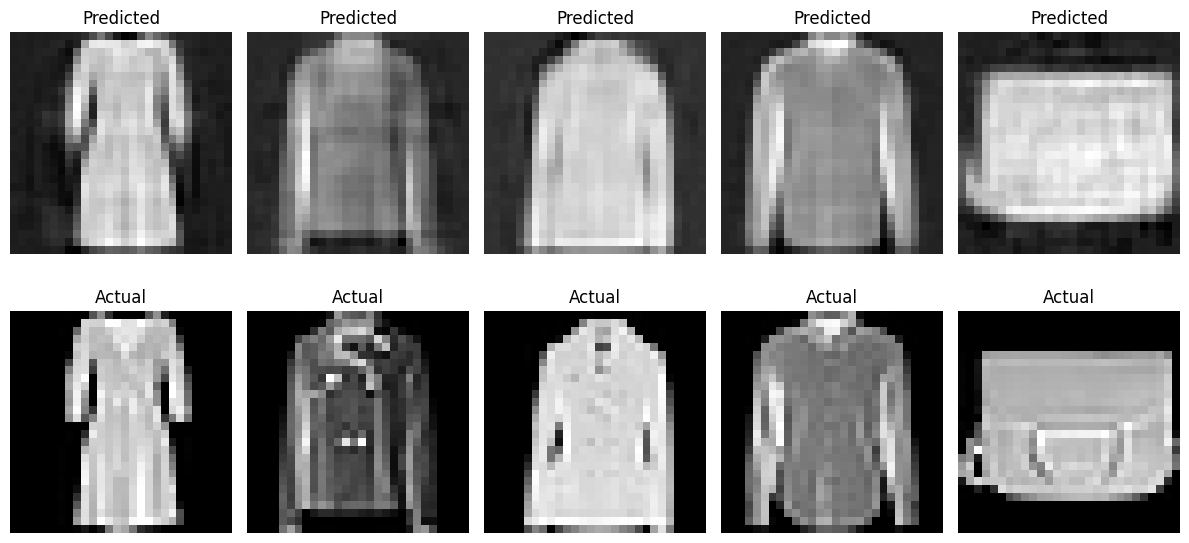

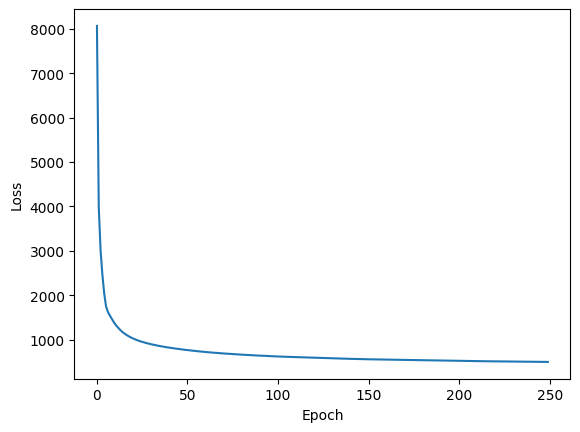




----------AutoEncoder with Latent Dimension 128----------
Epoch : 0	Loss : 7904.742179361979
Epoch : 25	Loss : 927.155620320638
Epoch : 50	Loss : 733.0323211669922
Epoch : 75	Loss : 646.1445688883464
Epoch : 100	Loss : 590.1638631184895
Epoch : 125	Loss : 549.7125457763672
Epoch : 150	Loss : 519.4350123087565
Epoch : 175	Loss : 493.95237325032554
Epoch : 200	Loss : 473.4269078572591
Epoch : 225	Loss : 456.4691462198893
Epoch : 250	Loss : 442.70020751953126


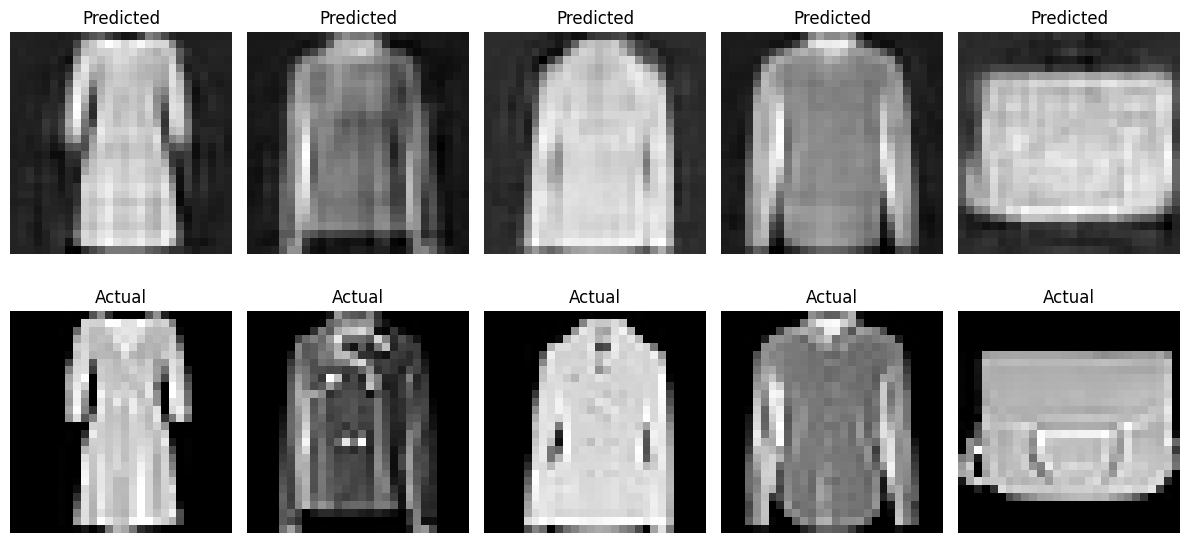

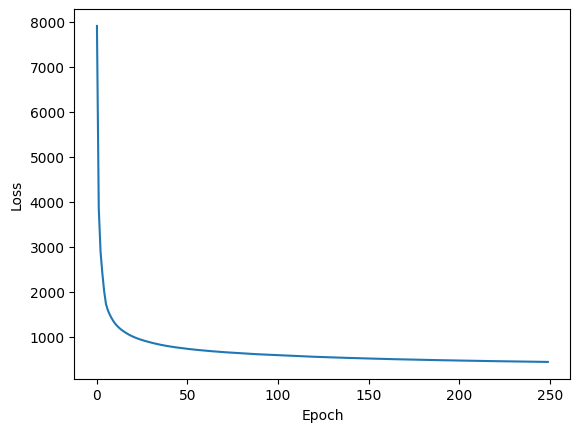




----------AutoEncoder with Latent Dimension 256----------
Epoch : 0	Loss : 7804.034008789063
Epoch : 25	Loss : 906.6986114501954
Epoch : 50	Loss : 716.8489217122395
Epoch : 75	Loss : 620.3534790039063
Epoch : 100	Loss : 560.3266204833984
Epoch : 125	Loss : 516.6002583821614
Epoch : 150	Loss : 483.41387939453125
Epoch : 175	Loss : 458.25191599527994
Epoch : 200	Loss : 437.0026499430339
Epoch : 225	Loss : 420.27808380126953
Epoch : 250	Loss : 404.85569966634114


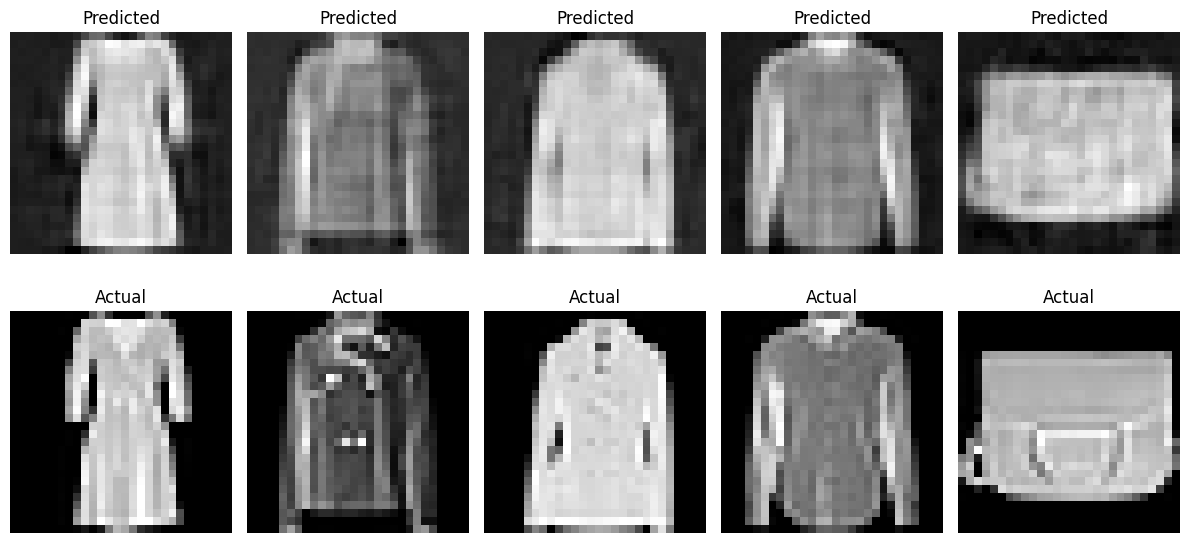

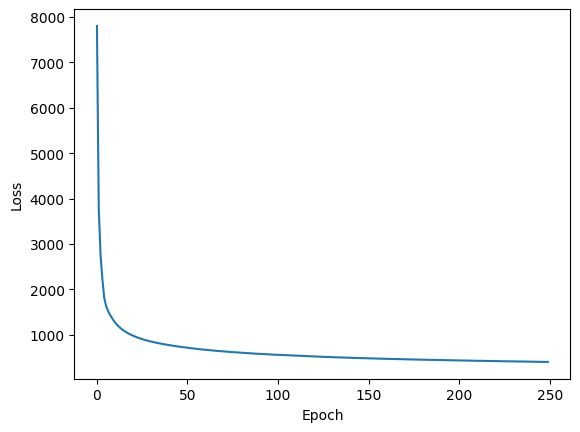

In [152]:
dims = [ 2 , 4 , 8 , 16 , 32 , 64 , 128 , 256]
epochs = 250
batch_size = 1000
Complete_loss = {}
testing_loss = []
training_time = []

for dim in dims:
    print(f"----------AutoEncoder with Latent Dimension {dim}----------")
    torch.manual_seed(12)
    model = AutoEncoder(dim).to(device)
    optim = Adam(model.parameters() , lr = 1e-4)
    loss_fn = nn.MSELoss()
    losses = []

    t = time.time()
    for epoch in range(epochs):
        total_loss = 0
        for i in range(0,len(x_train),batch_size):
            y_pred = model(x_train[i:i+batch_size])
            loss = loss_fn(y_pred , x_train[i:i+batch_size])
            total_loss = total_loss + loss.item()
            optim.zero_grad()
            loss.backward()
            optim.step()
        if epoch%(epochs//10) == 0 :
            print(f"Epoch : {epoch}\tLoss : {total_loss/(len(x_train)//batch_size)}")
        losses.append(total_loss/(len(x_train)//batch_size))    
    print(f"Epoch : {epoch+1}\tLoss : {total_loss/(len(x_train)//batch_size)}")
    t = time.time() - t
    training_time.append(t)
    
    with torch.no_grad():
        # Testing by encoding and decoding testing 5 of the testing data to visualise how good is the reconstruction
        y_pred = model(x_test[10:15]).cpu().reshape(5,28,28)
        fig , axes = plt.subplots(nrows=2 , ncols=5 , figsize=(12,6))
        for i in range(5):
            axes[0 , i].imshow(y_pred[i],cmap="gray")
            axes[0 , i].set_title("Predicted")
            axes[0 , i].axis("off")

            axes[1 , i].imshow(x_test[10+i].cpu().reshape(28,28),cmap="gray")
            axes[1 , i].set_title("Actual")
            axes[1 , i].axis("off")
        plt.tight_layout()
        plt.show()

        y_pred = model(x_test)
        loss = loss_fn(y_pred , x_test)
        testing_loss.append(loss.item())

    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()
    Complete_loss[dim] = losses

    print("\n\n")

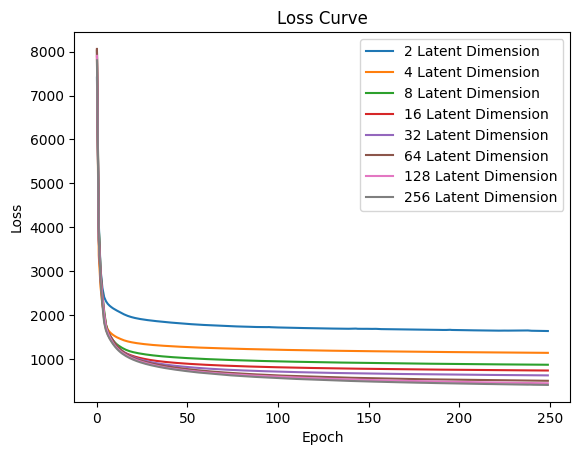

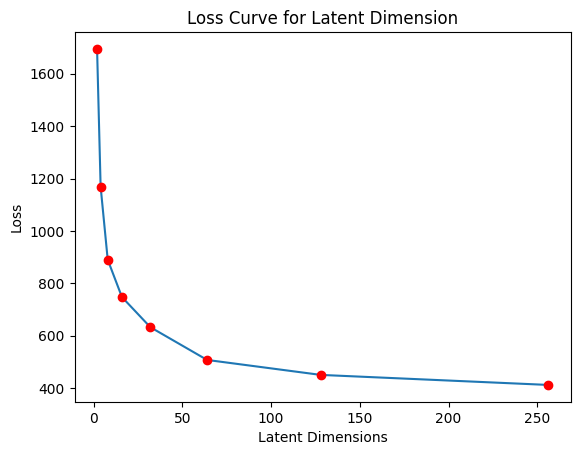

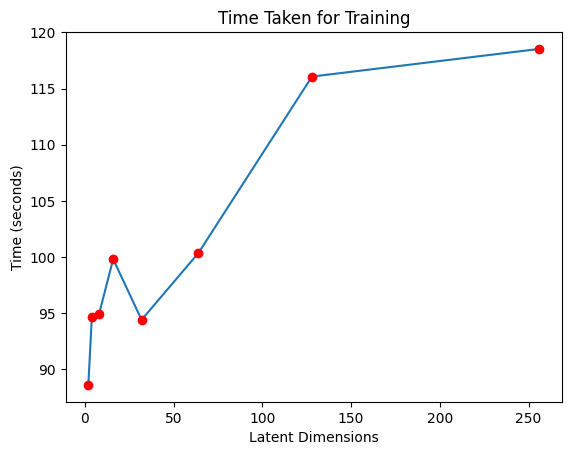

In [162]:
# Visualising all losses with latent dimensions throughout epochs
for lat_dim,loss in zip(Complete_loss.keys(),Complete_loss.values()):
    plt.plot(loss,label = f"{lat_dim} Latent Dimension")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Testing loss in testing data with latent dimensions
plt.plot(dims , testing_loss , marker = "o" , markerfacecolor="red" , markeredgecolor="red")
plt.xlabel("Latent Dimensions")
plt.ylabel("Loss")
plt.title("Loss Curve for Latent Dimension")
plt.show()

# Visualising how much time it took to train in given latent dimensions
plt.plot(dims , training_time , marker = "o" , markerfacecolor="red" , markeredgecolor="red")
plt.xlabel("Latent Dimensions")
plt.ylabel("Time (seconds)")
plt.title("Time Taken for Training")
plt.show()

Increase in Latent Dimensions does decrease loss but its change becomes less and less as we keep on increase the dimensions but training time increases very rapidly(except few cases) hence it is better to keep a suitable latent dimensions so as to keep all information for reconstruction and wouldn't take ages to train. Bottleneck size(latent dimension) should be precisely chosen also so that the model doesn't overfit.